# Motivation 

Climate change is often discussed as single global threat. However, the reality is far more nuanced. While industrialized nations have driven historical emissions in the pursuit of economic growth, the resulting disasters often strike hardest in regions with the smallest carbon footprints. This project was born from a simple but urgent premise: To act on a global crisis, we first have to understand the human experience behind the numbers.

We didn't just want to state facts. We wanted to build a data story that drives curiosity and encourages users to explore their own place within this global dynamic.

### What is your dataset? Why did you choose this/these particular dataset(s)?
To capture the full scope of this issue, we integrated six distinct datasets, each adding a layer of context to the climate narrative:

**Global Disaster Data (EM-DAT, 2000-2025)**: 
* This serves as our "impact" baseline. By tracking floods, storms, and droughts, we can visualize in which countries the effect of climate change is actually being felt.

**CO2 Emissions (EDGAR, 1970-2024)**: 
* This represents responsibility. It tracks the rise of industrialization and carbon output, allowing us to contrast historical emissions with modern-day suffering.

**Global Climate Opinion Survey (2024)**: 
* Since climate change is human-made, human sentiment is the variable. This data reflects how people across the globe experience and perceive the crisis in real-time.

**World Bank Economic Classification & GNI per Capita** : 
* Wealth is an important factor, for . We use these metrics to provide context for opinions and to add a dimension to interpret our Machine Learning results of the survey.

**United Nations Population (2024) Data**: 
* To ensure a fair comparison, we normalized our findings. A disaster in a small island nation is fundamentally different from one in a massive continent. Population data allows us to respect that. 

### What was your goal for the end user's experience?
Our goal was to create a guided data story. We want users to move beyond the headlines they already know and dive into the deeper context.

We designed this experience to be inclusive of every nation—whether wealthy or developing, large or small. By allowing users to toggle through different disaster types and economic lenses, we hope to foster a sense of collective responsibility. At its core, this project is meant to show that while our experiences with climate change are vastly different, the solution must be unified. We aim to leave the reader with a clear takeaway: Respect the responsibility, but prioritize the collective action. 


<hr>

## Dependencies

In [15]:
!pip install xlrd # Apparently xls files requires this specifically and we need it for the GNI data

import pandas as pd
import numpy as np
from re import sub
import textwrap

import matplotlib.pyplot as plt # just for the static plots in the explainer notebook
import seaborn as sns # just for the static plots in the explainer notebook
import plotly.express as px
import plotly.graph_objects as go

import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from scipy import linalg

from sklearn.metrics import recall_score, precision_score
from sklearn.metrics import confusion_matrix

template = 'plotly_white'

<hr>

# Survey analysis, People's Climate Vote - Basic Stats
### Peoples' Climate Vote Data
https://peoplesclimate.vote/data-center
* UNDP data for Peoples’ Climate Vote 2024
* 73 countries answering 15 survey questions
* 3.2 MB, 45785 rows, 17 total variables

### Economic classification
https://datahelpdesk.worldbank.org/knowledgebase/articles/906519-world-bank-country-and-lending-groups
* The World Bank data containing classification on income
* 118 kB, 240 rows, 40 columns
### GNI data
https://data.worldbank.org/indicator/NY.GNP.PCAP.CD
* The World Bank data containing GNI per capita internationally
* 157 kB, 271 rows, 70 columns
## Data Ceaning and preprocessing
The data cleaning had to be done quite meticulously since there is 3 datasets with varying amount of recorded countries. The dataset with least amount of countries is Peoples' climate vote containing 73 countries while the World Bank datasets both contained almost essentially all countries and various groupings. Therefore we merge with respect to the Peoples' climate data.

We merge all the data together to make a combined dataset with the 73 countries (by the ISO 3166 standard), ultimately containing question data, economic classification and GNI per capita. It is important to mention that both the World Bank datasets were quite messy excel files with a very poor structure. Therefore i manually explored the excel files and made some slices that made sense to extract the economic classification and GNI per capita for each dataset.

In regards to the economic classification there's high income, upper-high income, middle income, middle-lower income and low-cinome. For this project I decided to make it into a binary class of high income (high income classification) and non-high income (the remaining classifications). The reason for this is also cause i could see the high income countries were MUCH richer than the other economy groups.

The dataset is intentionally filtered by country, regardless of age and education. Peoples' Climate Vote data does have age and education, so it would have been possible to do more groupings, but that was not the focus in this project.

At last, we convert the merged data into a wide table where each column is a question-answer pair for each country, including the economy data for each country. It is worth mentioning that there is some data missing for 3 countries, so it leaves us with 70 countries for the further principal component analysis and clustering.

For summarizing the data, i made a plot that summarizes the questions across the categories in the Peoples' climate vote data. Personally, i think the real data analysis comes after with the unsupervised machine techniques from previous courses that i have applied.

## Data analysis
The final data analysis ended up revolving around principal component analysis (PCA) and clustering. PCA was used because survey data is complex and contains a lot of dimensions. By using PCA we can reduce the dimensionality and therefore actually plot the opinions in a representative way where to maximize the variance. It helps us discover hidden patterns in high dimensional data. Just by doing this and looking at a plot of the first two principal components, it is clear that two clusters appear. So it was natural to investigate it further with the economy data and clustering.

By using the wide data it was possible to cluster the PCA data using a Gaussian Mixture Model (GMM). Initially i used k-means because it is easier, but it makes more sense to use GMM since i noticed more elliptical / round and dense clusters. This GMM clustering helps separate the two clusters, and when also plotting the clustering along with the economy data, the real pattern appears that wealth naturally groups with opinion (clustered).

By using PCA and GMM, i learned that there naturally emerges a binary cluster pattern in opinions that match closely with the wealth gap we see. It is not really surprising, but it is nice to have real data supporting our ideas of how the world is.


In [16]:
class OpinionEconomy:
    pcv_columns_to_keep = [
        'Country',
        'Question Text',
        'Question Text (Short)',
        'Response',
        'Education',
        'Age',
        'Weighted Mean',
        'Category',
    ]
    country_mapping = {
        'Comoros (the)': 'Comoros',
        "Côte d'Ivoire": "Cote d'Ivoire",
        'Democratic Republic of the Congo': 'Congo, Dem. Rep.',
        'Dominican Republic (the)': 'Dominican Republic',
        'Egypt': 'Egypt, Arab Rep.',
        'Iran (Islamic Republic of)': 'Iran, Islamic Rep.',
        'Kyrgyzstan': 'Kyrgyz Republic',
        'Niger (the)': 'Niger',
        'Philippines (the)': 'Philippines',
        'Republic of Korea (the)': 'Korea, Rep.',
        'Russian Federation (the)': 'Russian Federation',
        'Sudan (the)': 'Sudan',
        'Tanzania (the United Republic of)': 'Tanzania',
        'United Kingdom of Great Britain and Northern Ireland (the)': 'United Kingdom',
        'United States of America (the)': 'United States',
    }

    def __init__(
        self,
        peoples_climate_vote: pd.DataFrame,
        economy_classification: pd.DataFrame,
        gni: pd.DataFrame,
    ):
        self.pcv_raw = peoples_climate_vote
        self.pcv = self.pcv_raw[self.pcv_columns_to_keep]
        self.pcv['Country'] = self.pcv['Country'].apply(lambda x: self.country_mapping[x] if x in self.country_mapping.keys() else x)
        self.pcv = self.pcv[
            (self.pcv['Education'] == 'All Education') & 
            (self.pcv['Age'] == 'All Ages') &
            (self.pcv['Response'] != "Don't know") & 
            (self.pcv['Country'] != 'Global') 
            ]

        self.ec = economy_classification.iloc[10:228, [0, 1, 39]]
        self.ec = self.ec.rename(columns={
                self.ec.columns[0]: 'Country Code',
                self.ec.columns[1]: "Country",
                self.ec.columns[2]: "Economy"
                }
            )

        self.gni = gni.iloc[3:269, [0, 1, 68]]
        self.gni = self.gni.rename(columns={
                self.gni.columns[0]: "Country",
                self.gni.columns[1]: "Country Code",
                self.gni.columns[2]: "GNI"
                }
            )

        self.data = self.build_wide_table()

        self.y_true = self.data['Economy']


    def build_wide_table(self):
        ecgni = self.ec.merge(self.gni, on='Country Code', how='inner', suffixes=('_eco', ''))[['Country', 'Economy', 'GNI']]
        ecgni['Economy'] = ecgni['Economy'].apply(lambda x: 'High income' if x == 'H' else 'Non-high income')

        wide = pd.concat([
            self.pcv['Country'],
            (
                self.pcv['Question Text (Short)'].map(lambda x: x.strip().lower().replace(" ", "_")) +
                '_' +
                self.pcv['Response'].map(lambda x: sub(r"[^\w]", "", "_".join(x.replace("-", " ").split()).lower())) 
            ).rename('Question Response'),
            self.pcv['Weighted Mean']
            ],
            axis=1).pivot(index = 'Country', columns ='Question Response', values='Weighted Mean')

        return wide.join(ecgni.set_index('Country')).dropna()

    def pca(self):
        scaler = StandardScaler()
        X = scaler.fit_transform(OE.data.drop('Economy', axis=1))
        pca = PCA(n_components = 10)
        X_pca = pca.fit_transform(X)

        components = pca.components_
        explained_variance_ratio = pca.explained_variance_ratio_
        
        print("Explained variance:", explained_variance_ratio)
        print("Cumulative:", np.cumsum(explained_variance_ratio))
        return X_pca, components , explained_variance_ratio
    
    def cluster(self, X_pca):
        gmm = GaussianMixture(
            n_components=2,
            covariance_type='full',
            random_state=42
        )
        
        gmm.fit(X_pca)               
        y_pred = gmm.predict(X_pca)
        centroids = gmm.means_
        covariances = gmm.covariances_
        clusters = gmm.n_components
        return y_pred, centroids, covariances, clusters

    def summarize_questions(self, to_html=False):
        subset = self.pcv_raw[(self.pcv_raw['Country']=='Global') & (self.pcv_raw['Age']=='All Ages') & (self.pcv_raw['Education']=='All Education')]
        categories = subset['Category'].unique()
        subset = subset.sort_values('Weighted Mean', ascending=True)

        def wrap_text(text, width=40):
            if pd.isna(text):
                return text
            wrapped = textwrap.fill(str(text), width=width)
            return wrapped.replace('\n', '<br>')

        subset['Question Text'] = subset['Question Text'].apply(lambda x: wrap_text(x, width=60))
        subset['Response'] = subset['Response'].apply(lambda x: wrap_text(x, width=30))

        majority_idx = subset.groupby('Question Text')['Weighted Mean'].transform(max) == subset['Weighted Mean']
        subset['is_majority'] = majority_idx

        majority_responses = (
            subset[subset['is_majority']]
            .set_index('Question Text')['Response']
            .to_dict()
        )

        unique_majority_responses = subset[subset['is_majority']]['Response'].unique()
        colors = px.colors.qualitative.Plotly
        majority_color_map = {resp: colors[i % len(colors)] for i, resp in enumerate(unique_majority_responses)}

        GREY = '#BBBBBB'

        default_category = "Peoples' perspective"
        if default_category not in categories:
            default_category = categories[0]  # fallback

        fig = go.Figure()

        for category in categories:
            cat_data = subset[subset['Category'] == category]

            for response in cat_data['Response'].unique():
                resp_data = cat_data[cat_data['Response'] == response]

                bar_colors = []
                for _, row in resp_data.iterrows():
                    q = row['Question Text']
                    if row['is_majority'] and majority_responses.get(q) == response:
                        bar_colors.append(majority_color_map[response])
                    else:
                        bar_colors.append(GREY)

                is_majority_trace = any(
                    row['is_majority'] and majority_responses.get(row['Question Text']) == response
                    for _, row in resp_data.iterrows()
                )

                fig.add_trace(go.Bar(
                    x=resp_data['Weighted Mean'],
                    y=resp_data['Question Text'],
                    name=response if is_majority_trace else 'Other responses',
                    orientation='h',
                    marker_color=bar_colors,
                    text=[
                        f"{row['Response']}<br>{row['Weighted Mean']:.1f}%"
                        for _, row in resp_data.iterrows()
                    ],
                    hovertemplate='%{text}<extra></extra>',
                    textposition='none',
                    visible=(category == default_category),
                    legendgroup=response if is_majority_trace else 'grey',
                    showlegend=False,
                    meta={'category': category}
                ))

        buttons = []
        for category in categories:
            visibility = [t.meta['category'] == category for t in fig.data]
            buttons.append(dict(
                label=category,
                method='update',
                args=[
                    {'visible': visibility},
                    {
                        'title.text': (
                            f'Global distribution of responses per question<br>'
                            f'<sup>Category: {category}</sup>'
                        ),
                    }
                ]
            ))

        default_idx = list(categories).index(default_category)

        fig.update_layout(
            margin=dict(t=120),
            updatemenus=[dict(
                buttons=buttons,
                direction='down',
                showactive=True,
                active=default_idx,
                x=1.0,        # moved to the right
                xanchor='right',
                y=1.25,
                yanchor='top'
            )],
            title=dict(
                text=(
                    f'Global distribution of responses by category<br>'
                    f'<sup>Category: {default_category}</sup>'
                ),
            ),
            barmode='stack',
            template=template,
            width=700,
            height=500,
            yaxis=dict(
                tickfont=dict(size=12),
                title=dict(text=''),
                ticklabelposition='outside',
                ticklabelstandoff=20,        
            ),
            xaxis=dict(
                visible=False,
                autorange='reversed'        
            ),
            uniformtext_minsize=8,
            uniformtext_mode='hide',
        )

        fig.show()
        if to_html:
            fig.write_html("pcv_response_distribution.html")
    
OE = OpinionEconomy(
    peoples_climate_vote = pd.read_excel('Peoples_Climate_Vote_Database_2024.xlsx'),
    economy_classification = pd.read_excel('OGHIST_2026_03_10.xlsx', sheet_name='Country Analytical History'), # https://datahelpdesk.worldbank.org/knowledgebase/articles/906519-world-bank-country-and-lending-groups
    gni = pd.read_excel('API_NY.GNP.PCAP.CD_DS2_en_excel_v2_463.xls') # https://data.worldbank.org/indicator/NY.GNP.PCAP.CD
)

In [17]:
def summarize_pca_loadings(X_pca, components, explained_variance_ratio, feature_names, pc_x=0, pc_y=1, top_n=10):
    loadings = components
    explained = explained_variance_ratio

    for pc_idx in [pc_x, pc_y]:
        pc_loadings = loadings[pc_idx]
        
        # Sort by absolute loading, descending
        order = np.argsort(np.abs(pc_loadings))[::-1][:top_n]
        
        print(f"\n{'─' * 55}")
        print(f"  PC{pc_idx + 1}  —  explains {explained[pc_idx]*100:.1f}% of variance")
        print(f"{'─' * 55}")
        print(f"  {'Variable':<35} {'Loading':>8}  {'Direction'}")
        print(f"  {'·' * 35} {'·' * 8}  {'·' * 9}")
        
        for i in order:
            direction = '▲ positive' if pc_loadings[i] > 0 else '▼ negative'
            print(f"  {feature_names[i]:<35} {pc_loadings[i]:>+8.3f}  {direction}")

    print(f"\n{'─' * 55}")
    print(f"  Combined top {top_n} by magnitude across both PCs")
    print(f"{'─' * 55}")
    print(f"  {'Variable':<35} {'PC{}'.format(pc_x+1):>6}  {'PC{}'.format(pc_y+1):>6}  {'Magnitude':>9}")
    print(f"  {'·' * 35} {'·' * 6}  {'·' * 6}  {'·' * 9}")

    combined = np.sqrt(loadings[pc_x]**2 + loadings[pc_y]**2)
    order = np.argsort(combined)[::-1][:top_n]
    for i in order:
        print(
            f"  {feature_names[i]:<35} "
            f"{loadings[pc_x, i]:>+6.3f}  "
            f"{loadings[pc_y, i]:>+6.3f}  "
            f"{combined[i]:>9.3f}"
        )

def gmm_ellipse_plotly(mean, covar, dims=(0, 2), n_points=100):
    idx = list(dims)
    covar_2d = covar[np.ix_(idx, idx)]
    mean_2d  = mean[idx]

    v, w = linalg.eigh(covar_2d)
    v = 2.0 * np.sqrt(2.0) * np.sqrt(v)   # axis lengths (2-sigma)
    u = w[0] / linalg.norm(w[0])           # principal direction

    angle = np.arctan2(u[1], u[0])         # rotation angle in radians

    t = np.linspace(0, 2 * np.pi, n_points)
    xs = (v[0] / 2) * np.cos(t)
    ys = (v[1] / 2) * np.sin(t)

    cos_a, sin_a = np.cos(angle), np.sin(angle)
    x_rot = cos_a * xs - sin_a * ys + mean_2d[0]
    y_rot = sin_a * xs + cos_a * ys + mean_2d[1]

    return x_rot, y_rot

def summarise_stats(y_true, y_pred):
    px.imshow(
        confusion_matrix(y_true, y_pred).T,
        labels=dict(x="Real economy type", y="GMM cluster", color="Count"),
        x=['Non-high GNI', 'High GNI',],
        y=['Cluster 2 (Non-high GNI)', 'Cluster 1 (High GNI)'],
        text_auto=True,
        template=template,
        color_continuous_scale=px.colors.sequential.Purples
    ).update_xaxes(side="top").show()

    print("GMM recall: ", recall_score(y_true, y_pred))
    print("GMM precision: ", precision_score(y_true, y_pred))

def build_scatter_fig(X_pca, y_true, y_pred, size, dim=2):

    if dim == 2:
        fig = px.scatter(
            x = X_pca[:, 0],
            y = X_pca[:, 1],
            color = y_true,
            symbol = y_pred,
            size = size
        )
    elif dim == 3:
        fig = px.scatter_3d(
            x = X_pca[:, 0],
            y = X_pca[:, 1],
            z = X_pca[:, 2],
            color = y_true,
            symbol = y_pred,
            size = size
        )
    else:
        print("Can't build a PCA scatter with dimension higher than 3")

    return fig

def build_cluster_fig(centroids, covariances, clusters, dim=2):
    colors = ['#636EFA', '#EF553B']
    label_map = {0: 'Cluster A', 1: 'Cluster B'}

    fig = go.Figure()

    for k in range(clusters):
        ex, ey = gmm_ellipse_plotly(
            mean=centroids[k],
            covar=covariances[k],
            dims=(0, 1)
        )

        fig.add_trace(go.Scatter(
            x=ex, y=ey,
            mode='lines',
            fill='toself',
            fillcolor=colors[k],
            opacity=0.3,
            line=dict(color=colors[k], width=2),
            name=label_map[k],
            showlegend=True
        ))

    fig_centroids = px.scatter(
        x=centroids[:, 0],
        y=centroids[:, 1],
    )

    fig_centroids.update_traces(
        marker_symbol='star' if dim == 2 else 'cross',
        marker_color='#00CC96',
        marker=dict(size=14),
        selector=dict(mode='markers')
    )
    for trace in fig_centroids.data:
        fig.add_trace(trace)

    return fig

def plot_pca_clustering(X, y_true, y_pred, centroids, covariances, clusters, size, dim=2, to_html=False):
    label_map = {0: 'Cluster A', 1: 'Cluster B'}
    mapped_labels = pd.Series(y_pred).map(label_map).values

    pca_fig = build_scatter_fig(X_pca, y_true, mapped_labels, size, dim=dim)

    if dim == 2:
        cluster_fig = build_cluster_fig(centroids, covariances, clusters, dim=dim)

        fig = go.Figure(data = pca_fig.data + cluster_fig.data)

        quadrant_labels = [
            (7,   5, "Status quo +<br>Optimistic"),
            (-3,  4, "Pro-action +<br>Optimistic"),
            (-4, -3, "Pro-action +<br>Pessimistic"),
            (8,  -4, "Status quo +<br>Pessimistic"),
            ]

        for x, y_pos, label in quadrant_labels:
            fig.add_annotation(
                x=x, y=y_pos,
                text=label,
                showarrow=False,
                font=dict(size=10, color='rgba(100,100,100,0.6)'),
                align='center'
            )
        
    elif dim == 3:
        fig = go.Figure(data = pca_fig.data)
    else:
        print("Cannot plot dimensions higher than 3. Pick either 1 or 2 lol")


    fig.update_layout(
        template=template,
        margin=dict(b=120),
        xaxis=dict(title=dict(
            text="PC1 (23.2%)<br>Demand for more action ↔ Keep status quo",
            standoff=20
        )),
        yaxis=dict(title=dict(
            text="PC2 (15.4%)<br>Climate change pessimism ↔ Climate change optimism"
        )),
        legend=dict(
            orientation='h',
            x=0.5,
            xanchor='center',
            y=-0.25,          
            yanchor='top',
        )
    )
    fig.show()

    if to_html:
        fig.write_html("pcv_pca_gmm.html")

def plot_choropleth(y_pred, country_iso, to_html=False):
    cluster_df = pd.DataFrame(
    [[pred] for pred in y_pred], index=country_iso, columns=['Cluster']
    )
    cluster_df = cluster_df.join(OE.gni.set_index('Country'))

    cluster_df['Cluster'] = cluster_df['Cluster'].map({0: 'Cluster A', 1: 'Cluster B'}).values

    fig = px.choropleth(
        cluster_df,
        locations="Country Code",
        color="Cluster",
        hover_name=cluster_df.index,
        color_discrete_map={'Cluster A': '#1d6996', 'Cluster B': '#cc503e'},
        category_orders={"Cluster": ["Cluster A", "Cluster B"]},
    )

    fig.update_layout(
        legend=dict(
            title=None,
            orientation='h',
            y=0,        
        ),
        margin=dict(l=20, r=20, t=0, b=0)
    )

    fig.show()
    if to_html:
        fig.write_html("pcv_choropleth.html")

In [18]:
# Main plots

# Fig 6
OE.summarize_questions(to_html = False)

# Fig 7
X_pca, components, explained_variance_ratio = OE.pca()
y_pred, centroids, covariances, clusters = OE.cluster(X_pca)

plot_pca_clustering(
    X_pca,
    OE.y_true,
    y_pred,
    centroids,
    covariances,
    clusters=clusters,
    size = OE.data['GNI'],
    dim = 2,
    to_html = False
    )

summarize_pca_loadings(
    X_pca,
    components,
    explained_variance_ratio,
    feature_names=OE.data.columns,
    pc_x = 0,   # PC1
    pc_y = 1,   # PC2
    top_n = 10
)

# Fig 8
plot_choropleth(
    y_pred,
    country_iso = OE.data.index,
    to_html = False
    )

Explained variance: [0.23180165 0.15365527 0.11144494 0.07314578 0.04674222 0.04137693
 0.03975496 0.03737223 0.02809588 0.02450081]
Cumulative: [0.23180165 0.38545692 0.49690186 0.57004764 0.61678987 0.65816679
 0.69792175 0.73529398 0.76338985 0.78789066]



───────────────────────────────────────────────────────
  PC1  —  explains 23.2% of variance
───────────────────────────────────────────────────────
  Variable                             Loading  Direction
  ··································· ········  ·········
  rich_countries_helping_poor_about_the_same_as_now   +0.242  ▲ positive
  teaching_about_climate_change_about_the_same_as_now   +0.241  ▲ positive
  teaching_about_climate_change_more    -0.238  ▼ negative
  protection_from_extreme_weather_about_the_same_as_now   +0.237  ▲ positive
  rich_countries_helping_poor_more_help   -0.233  ▼ negative
  worry_compared_to_last_year_about_the_same   +0.216  ▲ positive
  effects_on_big_decisions_a_lot        -0.209  ▼ negative
  strengthening_commitments_strengthen   -0.196  ▼ negative
  protection_from_extreme_weather_more_protection   -0.195  ▼ negative
  extreme_weather_experience_about_the_same_as_usual   +0.195  ▲ positive

───────────────────────────────────────────────────────
  

In [19]:
# Just some additional plots mainly for sanity check
plot_pca_clustering(
    X_pca,
    OE.y_true,
    y_pred,
    centroids,
    covariances,
    clusters=clusters,
    size = OE.data['GNI'],
    dim=3,
    to_html=False
    )

summarise_stats(list(map(lambda x: 1 if x == 'High income' else 0, OE.y_true)), y_pred)

GMM recall:  0.75
GMM precision:  0.7058823529411765


<hr>

## EM-DAT Disasters Data
* Center for Research on the Epidemiology of Disasters (CRED) and the World Health Organization (WHO)
* Different categories of disasters per 223 different country and affected people
* 6.1 MB, 16794 rows, 47 total variables

### Supporting data
* United Nations Population Prospect
* https://population.un.org/wpp/downloads?folder=Standard%20Projections&group=Most%20used
* data from 1950-2100 (partly projected population figures) available
* 35,787 rows

### Data Cleaning
The EM-DAT disaster dataset was first cleaned and standardized before being restricted to events occurring between 2000 and 2024, with 2025 being intentionally excluded to maintain consistency with the other datasets. The analysis focused exclusively on climate-related natural disasters, excluding technical or industrial events, as well as natural diseasters that are not related to climate change. The selected disaster categories — *Flood*, *Wildfire*, *Drought*, *Mass movement (wet)*, *Storm*, *Epidemic*, *Extreme temperature*, and *Glacial lake outburst flood* — were chosen based on the paper *“The impacts of climate change on the risk of natural disasters”* (2006) by Van Aalst, Maarten K.. After filtering, the resulting cleaned dataset contained 9,462 climate-related disaster events. 
In a second step, population data from the United Nations World Population Prospects (WPP 2024) dataset were prepared. 


### EM-DAT: 0. Setup & Data Loading

In [20]:
# ── Load EM-DAT
emdat = pd.read_csv('public_emdat.csv', sep=';', low_memory=False)

# Standardise column names (strip whitespace)
emdat.columns = emdat.columns.str.strip()

# Convert numeric cols
emdat['Total Affected'] = pd.to_numeric(emdat['Total Affected'], errors='coerce').fillna(0)
emdat['Total Deaths']   = pd.to_numeric(emdat['Total Deaths'],   errors='coerce').fillna(0)
emdat['Start Year']     = pd.to_numeric(emdat['Start Year'],     errors='coerce')

# Filter 2000-2024
emdat_all = emdat[(emdat['Start Year'] >= 2000) & (emdat['Start Year'] <= 2024)].copy()

# Climate-related disaster types of interest
CLIMATE_TYPES = [
    'Wildfire',
    'Epidemic',
    'Flood',
    'Drought',
    'Storm',
    'Extreme temperature',
    'Glacial lake outburst flood',
    'Mass movement (wet)',
]

# Normalise disaster type capitalisation for matching
emdat_all['Disaster Type Norm'] = emdat_all['Disaster Type'].str.strip().str.lower()
climate_types_lower = [t.lower() for t in CLIMATE_TYPES]

emdat_climate = emdat_all[emdat_all['Disaster Type Norm'].isin(climate_types_lower)].copy()

# Map back to display label with consistent capitalisation
type_map = {t.lower(): t for t in CLIMATE_TYPES}
emdat_climate['Disaster Type Display'] = emdat_climate['Disaster Type Norm'].map(type_map)

#print(f'EM-DAT rows (2000-2024): {len(emdat_all):,}')
#print(f'Climate rows            : {len(emdat_climate):,}')
#print(f'Disaster types found    : {emdat_climate["Disaster Type Display"].unique()}')

# ── Load WPP Population Data
wpp = pd.read_csv('WPP2024_Demographic_Indicators_Medium.csv', low_memory=False)
wpp.columns = wpp.columns.str.strip()

# Keep only country-level rows (ISO3_code is present, LocTypeID == 4 for countries)
wpp_countries = wpp[wpp['ISO3_code'].notna() & (wpp['ISO3_code'] != '')].copy()
wpp_countries = wpp_countries[['ISO3_code', 'Time', 'TPopulation1July']].copy()
wpp_countries.rename(columns={'ISO3_code': 'ISO', 'Time': 'Year', 'TPopulation1July': 'Population_thousands'}, inplace=True)
wpp_countries['Year'] = pd.to_numeric(wpp_countries['Year'], errors='coerce')
wpp_countries['Population_thousands'] = pd.to_numeric(wpp_countries['Population_thousands'], errors='coerce')
# WPP population is in thousands → convert to actual persons
wpp_countries['Population'] = wpp_countries['Population_thousands'] * 1000
wpp_countries = wpp_countries[['ISO', 'Year', 'Population']].dropna()

#print(f'\nWPP rows: {len(wpp_countries):,}')
#print(f'WPP years: {wpp_countries["Year"].min()}-{wpp_countries["Year"].max()}')

### EM-DAT: 1. Distribution of Disaster Impacts

In [21]:
affected_values = emdat_climate['Total Affected']
affected_values = affected_values[affected_values > 0]

mean_val = affected_values.mean()
median_val = affected_values.median()

log_values = np.log10(affected_values)

fig_dist = make_subplots(
    rows=2, cols=1,
    subplot_titles=[
        'Total Affected (Linear Scale)',
        'Total Affected (Log₁₀ Scale)'
    ],
    vertical_spacing=0.12
)

# ── TOP: Linear 
fig_dist.add_trace(go.Histogram(
    x=affected_values,
    nbinsx=80,
    marker_color='steelblue',
    hovertemplate='Affected: %{x:,.0f}<br>Count: %{y}<extra></extra>'
), row=1, col=1)

fig_dist.add_vline(
    x=mean_val,
    line_width=2,
    line_dash="dash",
    line_color="red",
    annotation_text=f"Mean: {mean_val:,.0f}",
    annotation_font=dict(color="red"),
    annotation_position="top",
    row=1, col=1
)

fig_dist.add_vline(
    x=median_val,
    line_width=2,
    line_dash="dot",
    line_color="black",
    annotation_text=f"Median: {median_val:,.0f}",
    annotation_font=dict(color="black"),
    annotation_position="bottom",
    row=1, col=1
)

# ── BOTTOM: Log 
fig_dist.add_trace(go.Histogram(
    x=log_values,
    nbinsx=80,
    marker_color='indianred',
    hovertemplate='log10(Affected): %{x:.2f}<br>Count: %{y}<extra></extra>'
), row=2, col=1)

fig_dist.add_vline(
    x=np.log10(mean_val),
    line_width=2,
    line_dash="dash",
    line_color="red",
    annotation_text=f"Mean: {mean_val:,.0f}",
    annotation_font=dict(color="red"),
    row=2, col=1
)

fig_dist.add_vline(
    x=np.log10(median_val),
    line_width=2,
    line_dash="dot",
    line_color="black",
    annotation_text=f"Median: {median_val:,.0f}",
    annotation_font=dict(color="black"),
    row=2, col=1
)

fig_dist.update_layout(
    title='Distribution of Disaster Impacts: Linear vs Log Scale',
    template='plotly_white',
    height=750,
    showlegend=False,
    bargap=0.05
)

fig_dist.update_xaxes(title_text='Total Affected', row=1, col=1)
fig_dist.update_xaxes(title_text='log₁₀(Total Affected)', row=2, col=1)
fig_dist.update_yaxes(title_text='Number of Events', row=1, col=1)
fig_dist.update_yaxes(title_text='Number of Events', row=2, col=1)

fig_dist.show()

**Linear-scale and log-scale distribution of total populations affected by climate-related disasters**
The figure analyses the focus variable of our analysis of the EM-DAT dataset, the number of _Total Affected_ by a diseaster. The visualisation shows the distribution of population exposure to climate-related disasters in the EM-DAT dataset, comparing a linear representation (top) with a logarithmic transformation (bottom). The linear view is highly right-skewed, with most events clustered at relatively low numbers of affected people, while a small number of extreme events dominate the upper range.

The visualisation using log₁₀ shows the underlying structure more clearly. The median affected population per event is approximately 5,400 people, while in contrast, the mean is approximately 606,392 people, which is substantially higher and reflects the strong influence of a small number of extreme disasters.

### EM-DAT: 2. Interactive World Map

In [22]:
# ── Aggregate: Total Affected per country / year / disaster type
agg = (
    emdat_climate
    .groupby(['ISO', 'Country', 'Start Year', 'Disaster Type Display'], as_index=False)['Total Affected']
    .sum()
)
agg.rename(columns={'Start Year': 'Year'}, inplace=True)

# "All" option: sum all climate types per country/year
agg_all = (
    agg.groupby(['ISO', 'Country', 'Year'], as_index=False)['Total Affected']
    .sum()
)
agg_all['Disaster Type Display'] = 'All Climate Related Disasters'

full_agg = pd.concat([agg, agg_all], ignore_index=True)

# ── Merge with population
full_agg = full_agg.merge(wpp_countries, on=['ISO', 'Year'], how='left')
full_agg['Total Affected per 1M'] = np.where(
    full_agg['Population'] > 0,
    full_agg['Total Affected'] / full_agg['Population'] * 1_000_000,
    np.nan
)

YEARS   = list(range(2000, 2025))
DD_OPTIONS = ['All Climate Related Disasters'] + sorted(CLIMATE_TYPES)

# ── Compute global colour scale limits (fixed across all years & types)
# Absolute
max_abs = full_agg[full_agg['Total Affected'] > 0]['Total Affected'].max()
min_abs = full_agg[full_agg['Total Affected'] > 0]['Total Affected'].min()
log_max_abs = np.log10(max_abs)
log_min_abs = np.log10(max(min_abs, 1))

# Per-1M
max_per1m = full_agg[full_agg['Total Affected per 1M'] > 0]['Total Affected per 1M'].max()
min_per1m = full_agg[full_agg['Total Affected per 1M'] > 0]['Total Affected per 1M'].min()
log_max_per1m = np.log10(max_per1m)
log_min_per1m = np.log10(max(min_per1m, 0.001))

#print(f'Abs range : {min_abs:,.0f} – {max_abs:,.0f}')
#print(f'Per-1M range: {min_per1m:,.2f} – {max_per1m:,.2f}')

traces_abs   = []  # absolute traces
traces_per1m = []  # per-1M traces

for dtype in DD_OPTIONS:
    for yr in YEARS:
        sub = full_agg[(full_agg['Disaster Type Display'] == dtype) & (full_agg['Year'] == yr)]

        # ── absolute ──
        log_vals_abs = np.where(sub['Total Affected'] > 0, np.log10(sub['Total Affected']), np.nan)
        hover_abs = [
            f"<b>{c}</b><br>Total Affected: {int(v):,}"
            for c, v in zip(sub['Country'], sub['Total Affected'])
        ]
        traces_abs.append(go.Choropleth(
            locations=sub['ISO'],
            z=log_vals_abs,
            zmin=log_min_abs,
            zmax=log_max_abs,
            colorscale='Spectral_r',
            showscale=True,
            colorbar=dict(
                title='Total Affected (log₁₀)',
                tickvals=[1, 2, 3, 4, 5, 6, 7, 8],
                ticktext=['10', '100', '1K', '10K', '100K', '1M', '10M', '100M'],
                len=0.6,
            ),
            text=hover_abs,
            hovertemplate='%{text}<extra></extra>',
            visible=False,
            name=f'{dtype}|{yr}|abs',
        ))

        # ── per 1M ──
        log_vals_per1m = np.where(
            sub['Total Affected per 1M'] > 0,
            np.log10(sub['Total Affected per 1M']),
            np.nan
        )
        hover_per1m = [
            f"<b>{c}</b><br>Total Affected per 1M: {v:,.1f}"
            for c, v in zip(sub['Country'], sub['Total Affected per 1M'].fillna(0))
        ]
        traces_per1m.append(go.Choropleth(
            locations=sub['ISO'],
            z=log_vals_per1m,
            zmin=log_min_per1m,
            zmax=log_max_per1m,
            colorscale='Spectral_r',
            showscale=True,
            colorbar=dict(
                title='Affected per 1M<br>Population (log₁₀)',
                tickvals=[-1, 0, 1, 2, 3, 4, 5],
                ticktext=['0.1', '1', '10', '100', '1K', '10K', '100K'],
                len=0.6,
            ),
            text=hover_per1m,
            hovertemplate='%{text}<extra></extra>',
            visible=False,
            name=f'{dtype}|{yr}|per1m',
        ))

N = len(DD_OPTIONS) * len(YEARS)  # traces per mode (abs / per1m)
all_traces = traces_abs + traces_per1m  # total 2*N traces

fig = go.Figure(data=all_traces)

# ── Helper: get trace index
def trace_idx(dtype_idx, year_idx, per1m=False):
    base = N if per1m else 0
    return base + dtype_idx * len(YEARS) + year_idx

# ── Default visibility: 2024, All Climate, absolute
DEFAULT_DTYPE_IDX = 0  # 'All Climate Related Disasters'
DEFAULT_YEAR_IDX  = YEARS.index(2024)
DEFAULT_PER1M     = True

visible_default = [False] * len(all_traces)
visible_default[trace_idx(DEFAULT_DTYPE_IDX, DEFAULT_YEAR_IDX, DEFAULT_PER1M)] = True
for i, tr in enumerate(fig.data):
    tr.visible = visible_default[i]

# ── Preparing data-arays

# Pre-compute data for all (dtype, year, mode) combinations
DATA_Z    = {}  # [dtype][mode][year] -> list of log values
DATA_LOC  = {}  # [dtype][year] -> list of ISO codes
DATA_TEXT = {}  # [dtype][mode][year] -> list of hover texts
DATA_CTRY = {}  # [dtype][year] -> list of country names

for dtype in DD_OPTIONS:
    DATA_Z[dtype]    = {'abs': {}, 'per1m': {}}
    DATA_TEXT[dtype] = {'abs': {}, 'per1m': {}}
    DATA_LOC[dtype]  = {}
    DATA_CTRY[dtype] = {}
    for yr in YEARS:
        sub = full_agg[(full_agg['Disaster Type Display'] == dtype) & (full_agg['Year'] == yr)].copy()
        DATA_LOC[dtype][yr]  = sub['ISO'].tolist()
        DATA_CTRY[dtype][yr] = sub['Country'].tolist()

        # absolute log z
        z_abs = [np.log10(v) if v > 0 else None for v in sub['Total Affected']]
        DATA_Z[dtype]['abs'][yr] = z_abs
        DATA_TEXT[dtype]['abs'][yr] = [
            f'<b>{c}</b><br>Total Affected: {int(v):,}'
            for c, v in zip(sub['Country'], sub['Total Affected'])
        ]

        # per-1M log z
        z_per = [np.log10(v) if (v and v > 0) else None for v in sub['Total Affected per 1M'].fillna(0)]
        DATA_Z[dtype]['per1m'][yr] = z_per
        DATA_TEXT[dtype]['per1m'][yr] = [
            f'<b>{c}</b><br>Affected per 1M pop: {v:,.1f}'
            for c, v in zip(sub['Country'], sub['Total Affected per 1M'].fillna(0))
        ]

# ── Build single-trace figure with dynamic updates

def build_map_figure():
    init_dtype = 'All Climate Related Disasters'
    init_year  = 2024
    init_mode  = 'abs'

    fig = go.Figure()

    # Single choropleth trace
    fig.add_trace(go.Choropleth(
        locations=DATA_LOC[init_dtype][init_year],
        z=DATA_Z[init_dtype][init_mode][init_year],
        zmin=log_min_abs,
        zmax=log_max_abs,
        colorscale='Spectral_r',
        showscale=True,
        colorbar=dict(
            title='Total Affected (log₁₀)',
            tickvals=[1, 2, 3, 4, 5, 6, 7, 8],
            ticktext=['10', '100', '1K', '10K', '100K', '1M', '10M', '100M'],
            len=0.65,
            x=1.0,
        ),
        text=DATA_TEXT[init_dtype][init_mode][init_year],
        hovertemplate='%{text}<extra></extra>',
        name='',
    ))

    # ── Slider steps (one per year)

    def make_slider_steps(dtype, mode):
        zmin = log_min_per1m if mode == 'per1m' else log_min_abs
        zmax = log_max_per1m if mode == 'per1m' else log_max_abs
        steps = []
        for yr in YEARS:
            steps.append(dict(
                method='update',
                args=[
                    {
                        'z':         [DATA_Z[dtype][mode][yr]],
                        'locations': [DATA_LOC[dtype][yr]],
                        'text':      [DATA_TEXT[dtype][mode][yr]],
                        'zmin':      [zmin],
                        'zmax':      [zmax],
                    },
                    {'title.text': f'<b>{dtype}</b> – Total Affected – {yr}'}
                ],
                label=str(yr),
            ))
        return steps

    init_steps = make_slider_steps(init_dtype, init_mode)

    sliders = [dict(
        active=YEARS.index(init_year),
        steps=init_steps,
        currentvalue=dict(prefix='Year: ', font=dict(size=14)),
        pad=dict(t=15, b=0),
        x=0.05,
        y=0.03,
        len=0.9,
    )]

    # ── Dropdown buttons

    def make_dropdown_buttons():
        buttons = []
        for mode, mode_label in [('abs', 'Absolute Count'), ('per1m', 'Per 1 Million Population')]:
            zmin = log_min_per1m if mode == 'per1m' else log_min_abs
            zmax = log_max_per1m if mode == 'per1m' else log_max_abs
            cb_title = 'Affected per<br>1M Population<br>(log₁₀)' if mode == 'per1m' else 'Total Affected<br>(log₁₀)'
            cb_tvals = [-1, 0, 1, 2, 3, 4, 5] if mode == 'per1m' else [1, 2, 3, 4, 5, 6, 7, 8]
            cb_ttext = ['0.1','1','10','100','1K','10K','100K'] if mode == 'per1m' else ['10','100','1K','10K','100K','1M','10M','100M']
            for dtype in DD_OPTIONS:
                new_steps = make_slider_steps(dtype, mode)
                buttons.append(dict(
                    label=f'{dtype} [{mode_label}]',
                    method='update',
                    args=[
                        {
                            'z':                    [DATA_Z[dtype][mode][init_year]],
                            'locations':            [DATA_LOC[dtype][init_year]],
                            'text':                 [DATA_TEXT[dtype][mode][init_year]],
                            'zmin':                 [zmin],
                            'zmax':                 [zmax],
                            'colorbar.title.text':  [cb_title],
                            'colorbar.tickvals':    [cb_tvals],
                            'colorbar.ticktext':    [cb_ttext],
                        },
                        {
                            'title.text': f'<b>{dtype}</b> – Total Affected – {init_year}',
                            'sliders[0].steps': new_steps,
                            'sliders[0].active': YEARS.index(init_year),
                        }
                    ],
                ))
        return buttons

    buttons = make_dropdown_buttons()

    updatemenus = [dict(
        buttons=buttons,
        direction='down',
        showactive=True,
        x=0.01,
        xanchor='left',
        y=1.10,
        yanchor='top',
        bgcolor='white',
        bordercolor='#ccc',
        font=dict(size=12),
    )]

    fig.update_layout(
        title=dict(
            text=f'All Climate Related Disasters – Total Affected – {init_year}',
            x=0.5, xanchor='center', font=dict(size=16), y=0.95
        ),
        geo=dict(
            showframe=False,
            showcoastlines=True,
            projection_type='natural earth',
            bgcolor='#eaf2ff',
            landcolor='#f5f5f0',
            coastlinecolor='#aaaaaa',
        ),
        updatemenus=updatemenus,
        sliders=sliders,
        margin=dict(l=20, r=20, t=130, b=30),
        annotations=[
            dict(
                text='Disaster Type & Normalisation:',
                x=0.01, y=1.2, xref='paper', yref='paper',
                showarrow=False, font=dict(size=12)
            )
        ],
        paper_bgcolor='white',
        plot_bgcolor='white',
        width=700,
        height=500
    )
    return fig

fig_map = build_map_figure()
#fig_map.write_html('em-dat_interactive_world_map.html')
fig_map.show()


**Global Climate Related Disasters per Country and Year, 2000-2024.**
The figure illustrates the global distribution and intensity of populations affected by climate-related disasters across countries and over time. The map is presented as an interactive choropleth world map in which countries are colour-coded according to the severity of disaster impacts. 
Users can explore two different perspectives of disaster impact: either the absolute number of affected people or the number of affected people per one million inhabitants, allowing both large-scale impact assessment and population-adjusted comparison between countries of different sizes. 
Through a dropdown menu, the visualisation further enables the selection of individual climate-related disaster categories, including floods, storms, droughts, wildfires, epidemics, and extreme temperatures, as well as an aggregated category combining all climate-related disasters.
To ensure comparability across all years and disaster categories, a fixed logarithmic colour scale is applied throughout the visualisation, allowing both smaller and extremely large disaster impacts to remain visually distinguishable.

**Interpretations:**
A typical consequence of anthropogenic climate change is an increase in the frequency and intensity of natural hazards. In this context, the term <em>climate-related disasters</em> is used to describe events that are either directly influenced or statistically amplified by climatic changes. These include wildfire, epidemic, flood, drought, storm, extreme temperature events, glacial lake outburst floods, and wet mass movement (e.g., landslides and debris flows triggered by soil saturation). See for reference: Van Aalst, M.K. (2006), The impacts of climate change on the risk of natural disasters. Disasters, 30: 5-18.
Empirical data from the EM-DAT data set covering the period from 2000 to 2024 indicate a clear spatial and temporal heterogeneity in exposure to such climate-related disasters. Compared to other global regions, residents of island nations and countries in Africa appear to be disproportionately affected. These countries are also mostly low emitters of CO₂.



### EM-DAT: 3. Static Map: Total Affected per 1M Population Summed Over All Years (2000–2024)

In [23]:
# Total affected per country, summed 2000-2024, for all climate disaster types combined
static_agg = (
    emdat_climate
    .groupby(['ISO', 'Country'], as_index=False)['Total Affected']
    .sum()
)

# Merge with average population (use 2012 as mid-point proxy)
pop_avg = (
    wpp_countries[wpp_countries['Year'].between(2000, 2024)]
    .groupby('ISO', as_index=False)['Population']
    .mean()
)
static_agg = static_agg.merge(pop_avg, on='ISO', how='left')
static_agg['Affected per 1M'] = np.where(
    static_agg['Population'] > 0,
    static_agg['Total Affected'] / static_agg['Population'] * 1_000_000,
    np.nan
)

static_agg['log_affected_per1m'] = np.where(
    static_agg['Affected per 1M'] > 0,
    np.log10(static_agg['Affected per 1M']),
    np.nan
)
static_agg['hover'] = static_agg.apply(
    lambda r: f"<b>{r['Country']}</b><br>Total Affected (2000–2024): {int(r['Total Affected']):,}<br>Per 1M pop: {r['Affected per 1M']:,.0f}",
    axis=1
)

fig_static = go.Figure(go.Choropleth(
    locations=static_agg['ISO'],
    z=static_agg['log_affected_per1m'],
    colorscale='Spectral_r',
    showscale=True,
    colorbar=dict(
        title='Total Affected per<br>1M Population (log₁₀)',
        tickvals=[2, 3, 4, 5, 6, 7, 8, 9],
        ticktext=['100', '1K', '10K', '100K', '1M', '10M', '100M', '1B'],
        len=0.65,
    ),
    text=static_agg['hover'],
    hovertemplate='%{text}<extra></extra>',
))

fig_static.update_layout(
    title=dict(
        text='Total Affected per 1M Population by Climate Disasters – Cumulative 2000–2024<br><sup>All climate-related disaster types combined | Logarithmic colour scale</sup>',
        x=0.5, xanchor='center', font=dict(size=15)
    ),
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth',
        bgcolor='#eaf2ff',
        landcolor='#f5f5f0',
        coastlinecolor='#aaaaaa',
    ),
    height=550,
    margin=dict(l=0, r=0, t=80, b=20),
)
#fig_static.write_html('em-dat_static_world_map.html')
fig_static.show()


**Global Climate Related Disasters per Country, cumulative for 2000-2024.**
Building upon the previous interactive year-by-year visualisation, this second map provides a cumulative long-term version of the climate-related disasters between 2000 and 2024. Instead of displaying diseasters for each year seperately, the visualisation aggregates all climate-related disaster events over the entire 25-year period and illustrates the total number of affected people relative to national population size. 
Compared to the previous interactive visualisation, which focused on temporal dynamics and yearly variation, this cumulative representation emphasizes structural long-term patterns and identifies countries that experienced persistently high levels of climate-related disaster impacts across the entire observation period.


### EM-DAT: 4. Top 10 Countries by Total Affected

In [24]:
# Top 10 – not normalised
top10_abs = (
    static_agg.nlargest(10, 'Total Affected')[['Country', 'Total Affected']]
    .sort_values('Total Affected')
)

# Top 10 – normalised per 1M
top10_norm = (
    static_agg.dropna(subset=['Affected per 1M'])
    .nlargest(10, 'Affected per 1M')[['Country', 'Affected per 1M']]
    .sort_values('Affected per 1M')
)

fig_top = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        'Top 10 Countries - Total Affected (Absolute)',
        'Top 10 Countries - Affected per 1M Population'
    ],
    horizontal_spacing=0.5
)

fig_top.add_trace(
    go.Bar(
        x=top10_abs['Total Affected'],
        y=top10_abs['Country'],
        orientation='h',
        marker_color='steelblue',
        hovertemplate='<b>%{y}</b><br>Total Affected: %{x:,.0f}<extra></extra>',
        name='Absolute',
    ),
    row=1, col=1
)

fig_top.add_trace(
    go.Bar(
        x=top10_norm['Affected per 1M'],
        y=top10_norm['Country'],
        orientation='h',
        marker_color='firebrick',
        hovertemplate='<b>%{y}</b><br>Affected per 1M: %{x:,.0f}<extra></extra>',
        name='Per 1M',
    ),
    row=1, col=2
)

fig_top.update_layout(
    title=dict(
        text='Top 10 Countries by Climate Disaster Impact (2000–2024)',
        x=0.5, xanchor='center'
    ),
    showlegend=False,
    height=450,
    template='plotly_white',
)
fig_top.update_xaxes(row=1, col=1, title='Total Affected')
fig_top.update_xaxes(row=1, col=2, title='Affected per 1 Million People')
#fig_top.write_html('em-dat_top10_by_climate_diseaster_impact.html')
fig_top.show()


# ── Separate figure: Top 10 per 1M population only

fig_top_norm = go.Figure()

fig_top_norm.add_trace(
    go.Bar(
        x=top10_norm['Affected per 1M'],
        y=top10_norm['Country'],
        orientation='h',

        marker_color='firebrick',

        hovertemplate=(
            '<b>%{y}</b><br>'
            'Affected per 1M: %{x:,.0f}<extra></extra>'
        ),

        name='Per 1M',
    )
)

fig_top_norm.update_layout(
    title=dict(
        text='Top 10 Countries by Climate Disaster Impact<br>per 1M Population (2000–2024)',
        x=0.5,
        xanchor='center'
    ),

    template='plotly_white',
    showlegend=False,

    height=650,
    width=500,

    margin=dict(l=20, r=20, t=80, b=40),
)

fig_top_norm.update_xaxes(
    title='Affected per 1 Million People'
)

fig_top_norm.update_yaxes(
    title=''
)

# Export
#fig_top_norm.write_html('em-dat_top10_per1m_population.html')

#fig_top_norm.write_html('em-dat_norm_top10_by_climate_diseaster_impact.html')
fig_top_norm.show()


**Top 10 Countries which are affected by climate-related disasters in 2000–2024**
* **In red:** The figure shows the top 10 countries that are most affected by climate-related disasters cumulatively over the period 2000–2024. The affected population is shown relative to the population size of each country, allowing a population-normalised comparison of disaster impact.
* **In blue:** The figure shows the top 10 countries that are most affected by climate-related disasters cumulatively over the period 2000–2024, based on absolute numbers of affected people, without normalisation by population size. As a result, countries with larger populations are more likely to appear with higher numbers of affected people when a disaster occurs.

**Limitations:**
To compare these two measures, the red visualisation expresses impacts relative to the number of inhabitants of each country. An alternative normalisation could have been based on the geographic size of countries, since larger countries may have a greater physical exposure to natural hazards and may also contain more features such as river systems that can contribute to flooding. However, the analysis focuses on population-based normalisation, since the EM-DAT variable “Total Affected” is defined in terms of people affected rather than affected area. Nevertheless, geographic size and spatial exposure may still influence the results to some extent.

**What the data shows:**
Among all observed populations, residents of Vanuatu represent the most frequently affected group. On average, individuals in Vanuatu were affected by four climate-related disaster events per person over the 2000–2024 observation period. In contrast, European countries exhibit comparatively low levels of exposure to climate-related disasters over the same 25-year period.

### EM-DAT: 5. Total Affected & Deaths & Number of Diseasters over Years (Stacked)

In [25]:
yearly_type = (
    emdat_climate
    .groupby(['Start Year', 'Disaster Type Display'])
    .agg(
        Total_Affected=('Total Affected', 'sum'),
        Total_Deaths=('Total Deaths', 'sum'),
        N_Disasters=('DisNo.', 'count')
    )
    .reset_index()
    .rename(columns={'Start Year': 'Year'})
)

colors = px.colors.qualitative.Bold

# Disaster Types
disaster_types = yearly_type['Disaster Type Display'].unique()

# Subplots
fig_yr = make_subplots(
    rows=3, cols=1,
    subplot_titles=[
        'Total Affected by Climate Disaster Type (Stacked) – 2000–2024',
        'Total Deaths by Climate Disaster Type (Stacked) – 2000–2024',
        'Number of Climate Disasters by Type (Stacked) – 2000–2024',
    ],
    vertical_spacing=0.10,
    shared_xaxes=True
)

# Traces
for i, disaster in enumerate(disaster_types):

    subset = yearly_type[
        yearly_type['Disaster Type Display'] == disaster
    ]

    color = colors[i % len(colors)]

    # Total Affected
    fig_yr.add_trace(
        go.Scatter(
            x=subset['Year'],
            y=subset['Total_Affected'],
            mode='lines',
            stackgroup='affected',
            name=disaster,
            line=dict(width=0.5, color=color),
            hovertemplate=(
                '%{x}<br>'
                f'{disaster}<br>'
                'Total Affected: %{y:,.0f}<extra></extra>'
            ),
            legendgroup=disaster,
        ),
        row=1, col=1
    )

    # Total Deaths
    fig_yr.add_trace(
        go.Scatter(
            x=subset['Year'],
            y=subset['Total_Deaths'],
            mode='lines',
            stackgroup='deaths',
            name=disaster,
            line=dict(width=0.5, color=color),
            hovertemplate=(
                '%{x}<br>'
                f'{disaster}<br>'
                'Total Deaths: %{y:,.0f}<extra></extra>'
            ),
            legendgroup=disaster,
            showlegend=False
        ),
        row=2, col=1
    )

    # Number of Disasters
    fig_yr.add_trace(
        go.Scatter(
            x=subset['Year'],
            y=subset['N_Disasters'],
            mode='lines',
            stackgroup='count',
            name=disaster,
            line=dict(width=0.5, color=color),
            hovertemplate=(
                '%{x}<br>'
                f'{disaster}<br>'
                'Disasters: %{y}<extra></extra>'
            ),
            legendgroup=disaster,
            showlegend=False
        ),
        row=3, col=1
    )

fig_yr.update_layout(
    height=950,
    template='plotly_white',
    title=dict(
        text='Climate Disaster Trends by Disaster Type (2000–2024)',
        x=0.5,
        xanchor='center'
    ),
    hovermode='x unified'
)

fig_yr.update_yaxes(title_text='Affected', row=1, col=1)
fig_yr.update_yaxes(title_text='Deaths', row=2, col=1)
fig_yr.update_yaxes(title_text='Count', row=3, col=1)
fig_yr.update_xaxes(title_text='Year', row=3, col=1)

fig_yr.show()


# ── Event frequency, absolute numbers, not stacked

events_year_type = (
    emdat_climate
    .groupby(['Start Year', 'Disaster Type'])
    .agg(N_Events=('DisNo.', 'count'))
    .reset_index()
    .rename(columns={'Start Year': 'Year'})
)

fig_events = go.Figure()

types = events_year_type['Disaster Type'].unique()
colors = px.colors.qualitative.Set2

for i, dtype in enumerate(types):
    subset = events_year_type[events_year_type['Disaster Type'] == dtype]

    fig_events.add_trace(go.Scatter(
        x=subset['Year'],
        y=subset['N_Events'],
        mode='lines',
        name=dtype,
        line=dict(width=2, color=colors[i % len(colors)]),
        hovertemplate=f'{dtype}<br>Year: %{{x}}<br>Events: %{{y}}<extra></extra>'
    ))

fig_events.update_layout(
    title='Climate Disaster Frequency by Type (2000–2024)',
    xaxis_title='Year',
    yaxis_title='Number of Events',
    template='plotly_white',
    height=500
)

fig_events.show()

**Temporal evolution of climate-related disasters by type (2000–2024), showing total affected population, deaths, and event frequency**
The figure illustrates temporal trends of climate-related disasters between 2000 and 2024, disaggregated by disaster type. The underlying data are aggregated by year and disaster category, summarising three key indicators: the total number of affected people, total deaths, and the number of recorded disaster events. Together, the stacked representation allows for the identification of both absolute trends and compositional changes across disaster types.
But since the absolute trends can be difficult to read from the stacked chart, in the second visualisation there are the absolute numbers visualized in a non-stacked way.

**What the data shows:**
The visualisations show that droughts for example tend to have a relatively low number of deaths, but a high number of affected people, which is fluctuating - even though the number of drought events is relatively stable over the years. With floods it seems to be similar. In contrary, extreme temperature events have in general a relative high number of deaths, but a low number of total affected people. So in this figure the different kinds of climate related diseasters can be explored further. 

**Interpretation:**
In the context of our data story it is important to notice is, that in the second visualisation the absolute number of floods and storms tend to rise over time, but in the first visualisation none of the three different categories (Total Affectes, Deaths, Event Count) have a clear rising development over time for the sum of the different diseaster types, even though several articles claim, that the number and severity of these climate related diseasters will rise over time. See for reference: Van Aalst, M.K. (2006), The impacts of climate change on the risk of natural disasters. Disasters, 30: 5-18.
So it is probably the case, that the time span from 2000 to 2024 is too short to see those kind of long-term developments for all categories. Since we did not want to put a focus on certain types of climate related diseasters, we did not elaborate on these different developments further.

### EM-DAT: 6. Heatmap: Total Affected by Diseaster Type & Year

In [26]:
climate_by_type_year = (
    emdat_climate
    .groupby(['Start Year', 'Disaster Type Display'])
    .agg(Total_Affected=('Total Affected', 'sum'))
    .reset_index()
    .rename(columns={'Start Year': 'Year'})
)

pivot_affected = climate_by_type_year.pivot(
    index='Disaster Type Display', columns='Year', values='Total_Affected'
).fillna(0)

# Log transform for visualisation
pivot_log = np.log10(pivot_affected.replace(0, np.nan))

fig_heat = go.Figure(go.Heatmap(
    z=pivot_log.values,
    x=pivot_log.columns.tolist(),
    y=pivot_log.index.tolist(),
    colorscale='Spectral_r',
    colorbar=dict(
        title='Total Affected (log₁₀)',
        tickvals=[2, 3, 4, 5, 6, 7, 8],
        ticktext=['100', '1K', '10K', '100K', '1M', '10M', '100M'],
    ),
    hovertemplate='<b>%{y}</b><br>Year: %{x}<br>Total Affected: %{customdata:,.0f}<extra></extra>',
    customdata=pivot_affected.values,
))
fig_heat.update_layout(
    title=dict(text='Heatmap: Total Affected by Disaster Type & Year', x=0.5, xanchor='center'),
    height=400, template='plotly_white',
    xaxis_title='Year', yaxis_title='Disaster Type',
)
fig_heat.show()

**Heatmap of total population affected by climate-related disasters by type and year, 2000–2024.**
The figure presents a heatmap of the total number of people affected by climate-related disasters between 2000 and 2024, disaggregated by disaster type and year. The underlying data are aggregated by summing all affected populations for each combination of disaster category and year. To improve comparability across highly skewed values, the data are transformed using a logarithmic scale (log₁₀).
This representation enables the identification of temporal and structural patterns in climate-related disaster impacts, highlighting periods of intensified impact (like extreme temperatures in 2008 and 2024 and wildfires in 2019) as well as disaster types that consistently contribute high levels of human exposure across the observed time span, like strom, flood and drought.

## CO2 emmission data - basic stats
* Data from the EU commission from 1970 - 2024
* Yearly CO2 Emissions for 225 countries
* 4.5 MB, 3534 rows
* https://edgar.jrc.ec.europa.eu/dataset_ghg2025
## Supporting data
* United Nations Population Prospect from 2024
* https://population.un.org/wpp/downloads?folder=Standard%20Projections&group=Most%20used

## Data Cleaning
Two data cleanings were performed. The first was to create a cleaned CO₂ data frame containing annual CO₂ emissions per country from 1970 to 2024, as well as a joined data frame containing summarised CO₂ and disaster data from 2000 to 2025, alongside supporting population data for 2024. 

The CO₂ dataset contains CO₂ emissions for each industry sector within a country. For our analysis, we want to look at total emissions per country per year. The first step in the data cleaning process was to add up all the industry emissions per country to generate one CO₂ value per year. The data also uses commas as decimal separators; these were replaced with dots and converted to floats. Missing values in the dataset are declared as NaN, which we replaced with 0 for easier calculations. The column head names were simplified and unused columns were deleted. Finally, the data set was pivoted to show each year as a column and country as a row.

In [27]:
#read data file
df_co2 = pd.read_csv("IEA_EDGAR_CO2_1970_2024_csv.csv", sep=';')

#Cleaning
id_vars = ['Name', 'Substance', 'ipcc_code_2006_for_standard_report_name','Country_code_A3']
value_vars = [col for col in df_co2.columns if col.startswith('Y_')]

df_co2 = df_co2.melt(id_vars=id_vars, value_vars=value_vars, 
                  var_name='Year', value_name='Emissions')

df_co2['Year'] = df_co2['Year'].str.replace('Y_', '').astype(int)

if df_co2['Emissions'].dtype == 'object':
    df_co2['Emissions'] = df_co2['Emissions'].astype(str).str.replace(',', '.').astype(float)

df_co2['Emissions'] = df_co2['Emissions'].fillna(0)

#rename
df_co2 = df_co2.rename(columns={'Name': 'Country'})
df_co2 = df_co2.rename(columns={'Emissions': 'Emissions (kton)'})
df_co2 = df_co2.rename(columns={'Country_code_A3': 'ISO'})

#Aggregation
df_co2 = df_co2.groupby(['Country', 'Year', 'ISO'])['Emissions (kton)'].sum().reset_index()

df_co2_pivot = df_co2.pivot(index='Country', columns='Year', values='Emissions (kton)')
df_co2_pivot.head()

unique_countries_co2 = df_co2['Country'].nunique()
print(f"There are {unique_countries_co2} unique countries in df_co2.")


There are 225 unique countries in df_co2.


## Data Cleaning & Joining Data sets
Three data sets (CO₂ data, disaster data from 2000–2024, and supporting population data from 2024) were joined using the ISO country code to ensure consistency. As there was only a small amount of data for "glacial lake outburst flood", it was deleted from this data frame, as it would no longer be possible to establish sufficient correlation with it. The other disaster types remained the same and were summed up over all existing years. 
The population data was filtered to the population in 2024. Only the country name, the population on 1 January and the ISO code were kept. As the population was estimated by the UN, the value needed to be scaled to 1000. 'Injustice_Index' and 'Affected_per_100k' were calculated for later visualisation. The number of unique countries was also printed for quick analysis and inclusion in the website text.

In [28]:
# data aggregation with emdat and population data

# sum up all CO2 data per contry from 1970-2024, EDGAR data
df_co2_total = df_co2.groupby(['ISO', 'Country'])['Emissions (kton)'].sum().reset_index()

# Prepare climat disasters
# Galcial lake outburst flood seams to be not relevant
climate_disasters = ['Flood', 'Storm', 'Drought', 'Wildfire', 
                    'Extreme temperature', 
                    'Epidemic', 'Mass movement (wet)'
                    ]
#get emdat data , disaster data
df_emdat = pd.read_csv("public_emdat.csv", sep=";", encoding="utf-8", low_memory=False)
df_emdat["Total Affected"] = pd.to_numeric(df_emdat["Total Affected"], errors="coerce")

#summing up all total affected from 2000-2025 for all climate disasters
df_climate_emdat = df_emdat[df_emdat['Disaster Type'].isin(climate_disasters)]
df_affected = df_climate_emdat.groupby('ISO')['Total Affected'].sum().reset_index()


# Merge the datasets
df_correlation = pd.merge(df_co2_total, df_affected, on='ISO')

# Create the Log-Log Scatter Plot
df_correlation['Log_Emissions'] = np.log10(df_correlation['Emissions (kton)'] + 1)
df_correlation['Log_Affected'] = np.log10(df_correlation['Total Affected'] + 1)

# add population data for 2024
df_pop = pd.read_csv("WPP2024_Demographic_Indicators_Medium.csv", low_memory=False) 
latest_year = 2024
df_pop_latest = df_pop[(df_pop['Time'] == latest_year) & (df_pop['Variant'] == 'Medium')]

# Keep only necessary columns and rename for merging
df_pop_clean = df_pop_latest[['Location', 'TPopulation1Jan', 'ISO3_code']].rename(
    columns={'Location': 'Country', 'TPopulation1Jan': 'Population', 'ISO3_code':'ISO'}
)
#get absolut values
df_pop_clean['Population'] = df_pop_clean['Population'] * 1000

# Merge with your existing Correlation DataFrame
df_final = pd.merge(
    df_correlation, 
    df_pop_clean.drop(columns=['Country']), 
    on='ISO', 
    how='inner'
)

# Calculate "Injustice per Capita"
# How many affected people per 100,000 citizens?
df_final['Affected_per_100k'] = (df_final['Total Affected'] / df_final['Population']) #* 100000

# Injustice Index : countries that suffer the most or least relative to what they contribute
df_final = df_final[df_final['Emissions (kton)'] > 0]
df_final['Injustice_Index'] = df_final['Total Affected'] / df_final['Emissions (kton)']

unique_countries_count = df_final['Country'].nunique()
print(f"There are {unique_countries_count} unique countries in df_final.")

df_final

There are 207 unique countries in df_final.


,ISO,Country,Emissions (kton),Total Affected,Log_Emissions,Log_Affected,Population,Affected_per_100k,Injustice_Index
0,AFG,Afghanistan,2.426183e+05,33697554.0,5.384925,7.527598,42044654.0,0.801471,138.891247
1,AGO,Angola,9.650389e+05,9190344.0,5.984545,6.963332,37312856.0,0.246305,9.523289
2,AIA,Anguilla,7.260641e+02,15000.0,2.861573,4.176120,14523.0,1.032844,20.659334
3,ALB,Albania,2.776321e+05,918261.0,5.443471,5.962967,2801661.0,0.327756,3.307474
4,ARE,United Arab Emirates,5.723264e+06,534.0,6.757644,2.728354,10839131.0,0.000049,0.000093
...,...,...,...,...,...,...,...,...,...
202,WSM,Samoa,1.017555e+04,18320.0,4.007601,4.262949,217342.0,0.084291,1.800394
203,YEM,Yemen,6.393453e+05,3295315.0,5.805736,6.517897,39987261.0,0.082409,5.154202
204,ZAF,South Africa,1.923527e+07,31495584.0,7.284098,7.498250,63627884.0,0.494997,1.637387
205,ZMB,Zambia,2.376908e+05,18040460.0,5.376014,7.256248,21017548.0,0.858352,75.898867


## Exploratory Data analysis - CO2 Emissions

This section presents the data analysis of CO₂ emissions. To analyse this data, a simple line chart was first created to show the development of CO₂ emissions over the past years from 1970 to 2024. This shows a constant rise in emissions, with only a few drops in the data that seem to be related to global crises such as the financial crisis of 2008 and the Coronavirus pandemic in 2020.  

Next, we calculate a bar chart showing the amount of CO₂ in kton for the number of countries in our focus year, 2024, to see how CO₂ emissions are distributed. This shows the main issue we had with this data, which is that we have  extreme outliers, with China being the biggest emitter and far ahead of all other countries. To make sense of the data and visualise it adequately, it is scaled to log₁₀, which is shown in the next bar chart in this notebook. This shows an almost normal distribution, with a large number of countries on the lower end of CO₂ emissions. In any case, this log₁₀ distribution is easier to visualise and will therefore be used primarily for the rest of the analysis. Due to the magnitude, it is not as easy to interpret, but we have tried to compensate for this with clear descriptions and explanations on the website. 

To provide more facts for the website text, the top three biggest emitters are plotted in a bar chart. For the year 2024, these are China, the USA and India. Together, they emitted 20,910,722 kt. Shockingly, the remaining 222 countries in the dataset need to be combined to equal this figure. The absurdity of the situation is highlighted by the presentation of a bar chart, which is unreadable due to the number of countries included, and which shows all 222 remaining countries alongside the top three emitters. 

We conclude this analysis with two maps showing CO₂ emissions per country. The first uses Log10 data for all 54 years and has a slider to navigate through the years. The Log10 data provides a nuanced perspective, even highlighting the subtle differences between countries. It clearly shows that the Global South is emitting more than the Global North, providing an initial indication of the inequality of climate change that we wanted to highlight. The second map summarises all emissions from 1970 to 2024 per country and uses absolute values. This makes the inequality even clearer, showing that China, the USA, India, Russia and Germany were mainly responsible for CO₂ emissions.

In [29]:
# Global Emissions per Year
global_trend = df_co2.groupby('Year')['Emissions (kton)'].sum().reset_index()
fig = px.line(
    global_trend, 
    template = 'plotly_white',
    x='Year', 
    y='Emissions (kton)',
    title='Global Emission Distribution (1970-2024)',
    labels={'Emissions (kton)': 'Total Emissionen (kton)', 'Year': 'Year'}
)

fig.update_traces(line=dict(color='darkred', width=3))
fig.update_layout(
    yaxis=dict(tickformat='.0f'),
    hovermode="x unified" 
)
#fig.write_html("line_global_co2_1970-2024.html", include_plotlyjs="cdn")

fig.show()

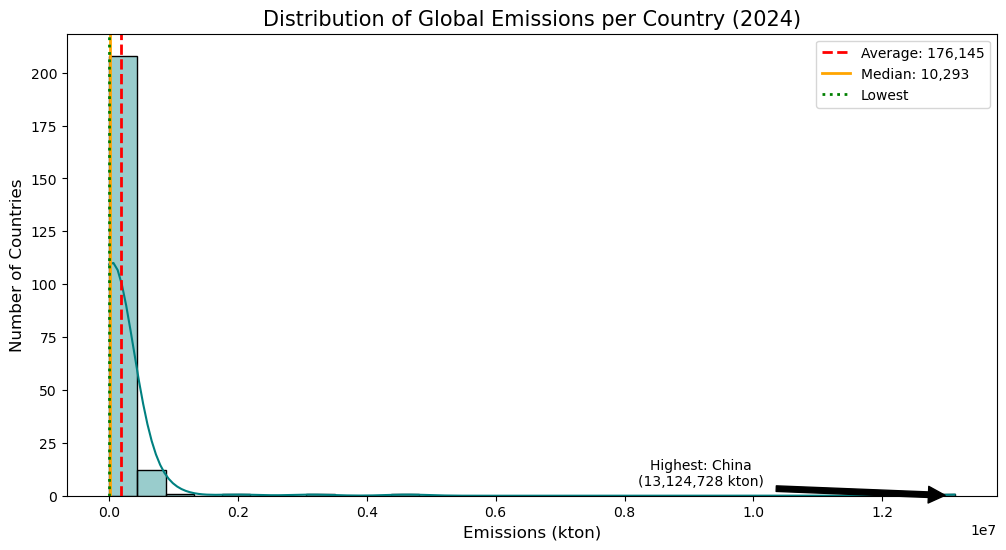

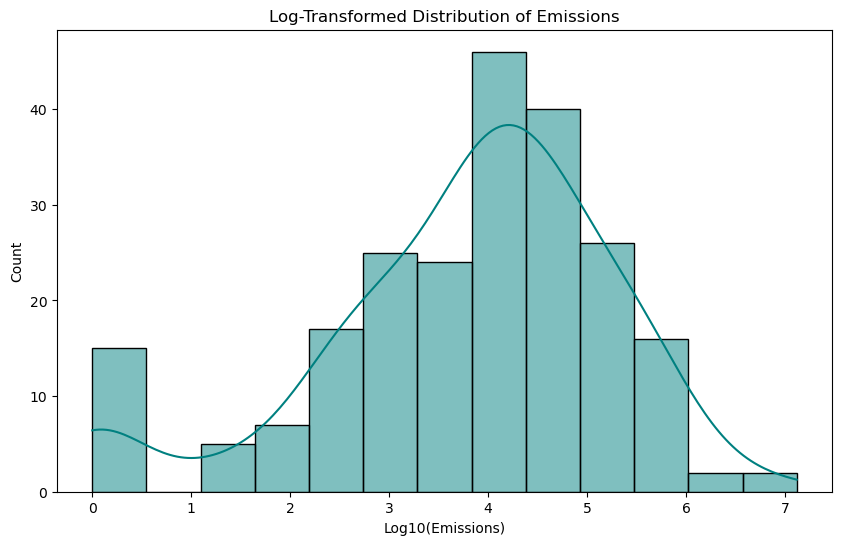

In [30]:
# Assumes df_co2 is already loaded/created earlier in the notebook.
# Recompute latest_year and df_2024 from df_co2 to be safe
latest_year = df_co2['Year'].max()

# Select rows for latest year and keep both Country and Emissions for later use
_df_latest = df_co2[df_co2['Year'] == latest_year][['Country', 'Emissions (kton)']].copy()

# Ensure Emissions are numeric (this is fine)
_df_latest['Emissions (kton)'] = pd.to_numeric(_df_latest['Emissions (kton)'], errors='coerce')

# IMPORTANT FIX: Ensure 'Country' is treated as string/object, not mistakenly coerced to numeric
# The error suggests a prior attempt tried to convert a concatenated string of countries to numeric.
# We explicitly cast Country to string to avoid any accidental numeric conversions.
_df_latest['Country'] = _df_latest['Country'].astype(str)

# Create a clean numeric Series for plotting/stats, but keep it as a Series of numbers only
# Also keep a properly indexed country Series for lookups
emissions_series = _df_latest['Emissions (kton)']
country_series = _df_latest['Country']

# 2. Calculate Key Statistics (skip NaNs)
mean_val = emissions_series.mean(skipna=True)
median_val = emissions_series.median(skipna=True)
min_val = emissions_series.min(skipna=True)
max_val = emissions_series.max(skipna=True)

# Identify country with max emissions (handle all-NaN edge case)
if emissions_series.notna().any():
    max_idx = emissions_series.idxmax()
    # Guard against potential misalignment by ensuring index exists in country_series
    max_country = country_series.loc[max_idx] if max_idx in country_series.index else 'N/A'
else:
    max_country = 'N/A'

# 3. Create the Plot
plt.figure(figsize=(12, 6))

# Plot the distribution (The "Bell") - drop NaNs
sns.histplot(emissions_series.dropna(), kde=True, color="teal", bins=30, alpha=0.4)

# Add Vertical Lines for Stats (only if they are finite)
if np.isfinite(mean_val):
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Average: {mean_val:,.0f}')
if np.isfinite(median_val):
    plt.axvline(median_val, color='orange', linestyle='-', linewidth=2, label=f'Median: {median_val:,.0f}')
if np.isfinite(min_val):
    plt.axvline(min_val, color='green', linestyle=':', linewidth=2, label='Lowest')

# 4. Annotate the "Outlier" (The Highest) if available
if np.isfinite(max_val):
    plt.annotate(
        f'Highest: {max_country}\n({max_val:,.0f} kton)',
        xy=(max_val, 0),
        xytext=(max_val * 0.7 if max_val > 0 else 0.1, 5),
        arrowprops=dict(facecolor='black', shrink=0.05),
        horizontalalignment='center'
    )

# Formatting
plt.title(f'Distribution of Global Emissions per Country ({latest_year})', fontsize=15)
plt.xlabel('Emissions (kton)', fontsize=12)
plt.ylabel('Number of Countries', fontsize=12)
plt.legend()

plt.show()

# Apply a log10 transformation (drop NaNs, add 1 to avoid log(0))
data_log = np.log10(emissions_series.dropna() + 1)

plt.figure(figsize=(10, 6))
sns.histplot(data_log, kde=True, color="teal")
plt.title('Log-Transformed Distribution of Emissions')
plt.xlabel('Log10(Emissions)')
plt.show()


# Also preserve df_2024 for downstream cells that expect it to exist as a DataFrame
# Create a two-column DataFrame with Country and Emissions for latest year
# (This mirrors earlier cells that used df_2024 with both columns.)
df_2024 = _df_latest.copy()

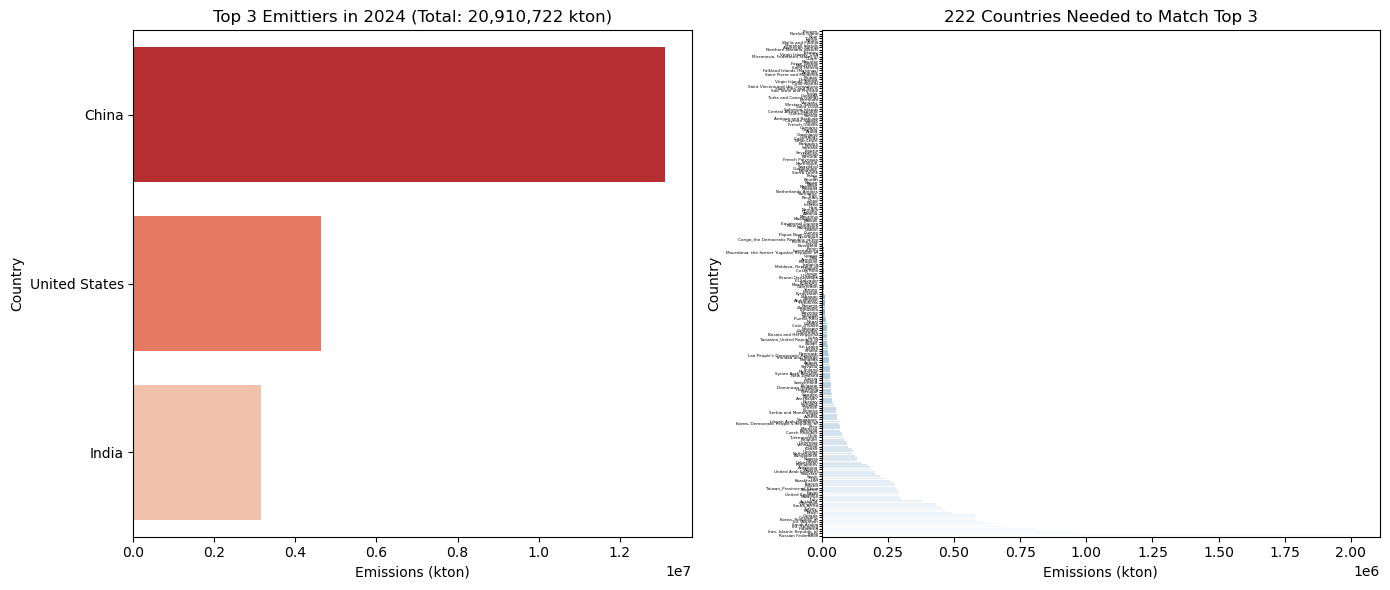

Top 3 total emissions: 20,910,722 kton
Number of bottom countries needed to match this: 222


In [31]:
# Prepare data for the latest year (2024)
latest_year = 2024
df_2024 = df_co2[df_co2['Year'] == latest_year].sort_values('Emissions (kton)', ascending=False)

# Top 5 Emitters
top_5 = df_2024.head(3).copy()
sum_top_5 = top_5['Emissions (kton)'].sum()

# Find how many bottom countries are needed to equal the sum_top_5
df_bottom_up = df_2024.sort_values('Emissions (kton)', ascending=True).copy()
df_bottom_up['Cumulative'] = df_bottom_up['Emissions (kton)'].cumsum()

# Filter until we reach the threshold
bottom_needed = df_bottom_up[df_bottom_up['Cumulative'] <= sum_top_5]
count_bottom_needed = len(bottom_needed)

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Top 5
sns.barplot(data=top_5, x='Emissions (kton)', y='Country', ax=ax1, palette='Reds_r')
ax1.set_title(f'Top 3 Emittiers in 2024 (Total: {sum_top_5:,.0f} kton)')

# How many countries needed to match?
sns.barplot(data=bottom_needed, x='Emissions (kton)', y='Country', ax=ax2, palette='Blues_r')
ax2.set_yticklabels(ax2.get_yticklabels(), fontsize=3)
ax2.tick_params(axis='y', pad=0.5, length=2)
ax2.set_title(f'{count_bottom_needed} Countries Needed to Match Top 3')

plt.tight_layout()
plt.show()

print(f"Top 3 total emissions: {sum_top_5:,.0f} kton")
print(f"Number of bottom countries needed to match this: {count_bottom_needed}")

In [32]:
df_co2['Log_Emissions'] = np.log10(df_co2['Emissions (kton)'] + 1)

min_log = df_co2['Log_Emissions'].min()
max_log = df_co2['Log_Emissions'].max()

#map
fig = px.choropleth(
    df_co2,
    locations="Country",
    locationmode="country names",
    color="Log_Emissions",
    hover_name="Country",
    animation_frame="Year",
    color_continuous_scale=px.colors.diverging.Spectral_r,
    # HIER fixieren wir die Range:
    range_color=[min_log, max_log], 
    title="Global CO2-Emissions (1970-2024)",
    subtitle="Values scaled to Log10. This helps to show even small differences in Emission.",
    labels={'Log_Emissions': 'Emissions (Log10 kton)'}
)

#fig.write_html("co2_emissions_perYear_map_scaled_Log10.html", include_plotlyjs="cdn")

fig.show()


In [33]:
#adding all years together
df_co2['Total Emissions (kton)'] = df_co2.groupby('Country')['Emissions (kton)'].transform('sum')

# map
fig = px.choropleth(
    df_co2,
    locations="Country",
    locationmode="country names",
    color="Total Emissions (kton)",
    hover_name="Country",
    color_continuous_scale=px.colors.diverging.Spectral_r,
    title="Global CO2-Emissions (Summed Up 1970-2024)",
    labels={'Emissions': 'Emissions (kton)'}
)

#fig.write_html("co2_emissions_map_TotalSum_1970-2024.html", include_plotlyjs="cdn")

fig.show()

## Exploratory Data analysis - CO2, Disasters & Population 

We wanted to perform some statistical analysis to quantify the effects that we had already identified and interpreted from the above analysis. Therefore, correlation was calculated. This showed that there is a positive correlation between the amount of CO₂ emitted by a country and the number of people affected by natural disasters in that country. This means that if a country emits more, it is also affected more. When we included population data in the correlation, it also showed that this was mainly due to countries that emit more also having a stronger population. Taking this into consideration, we divided the number of affected people by the population of the country and ran the correlation again. This showed that there is actually a negative correlation between the number of people affected per capita and the amount of CO₂ emitted. This suggests that countries are more responsible for the effects of climate change than for their CO₂ emissions.

Lastly, we created an "Injustice Index" to measure the gap between a country's contribution to climate change and the damage it suffers. We calculated this by taking the total number of people affected by disasters and dividing it by the country's total CO₂ emissions.This ratio allows us to see if countries are suffering in proportion to how much they emit.
* A high number represents a major injustice: these countries suffer a high human cost despite having very low emissions.
* A low number shows the opposite: these countries have high emissions but experience very little domestic suffering, likely due to better infrastructure and wealth.
When we sorted the results, a clear pattern emerged. The countries suffering the most are almost entirely from the Global South, such as Somalia, Niger, and the Marshall Islands. Meanwhile, the countries suffering the least relative to their emissions are mainly in the Global North, such as Sweden, Germany, and Denmark. To visualize this global divide, we plotted the index on a world map, showing at a glance who is responsible for climate change versus who is paying the price.



In [34]:
fig = px.scatter(
    df_final, 
    x='Emissions (kton)', 
    y='Total Affected',
    size='Population',
    hover_name='Country',
    log_x=True, 
    log_y=True,
    size_max=60, 
    title=f"Climate Injustice: Responsibility vs. Impact ({latest_year})",
    labels={
        'Emissions (kton)': 'Total CO2 Emissions (log scale)',
        'Total Affected': 'Total People Affected by Climate Disasters (log scale)'
    },
    template="plotly_white"
)
fig.update_traces(marker=dict(sizemin=2))
fig.show()

In [35]:
fig = go.Figure()

# 2. Schleife für jeden Katastrophentyp (Punkte + Linie)
for d_type in climate_disasters:
    # Merge
    df_temp = df_emdat[df_emdat['Disaster Type'] == d_type]
    df_aff = df_temp.groupby(['ISO', 'Country'])['Total Affected'].sum().reset_index()
    df_merged = pd.merge(df_co2_total, df_aff, on='ISO', how='left')
    df_merged = pd.merge(df_merged, df_pop_clean, on='ISO', how='inner')
    
    # Use 1 for 0-affected to handle log scale
    df_merged['Total Affected'] = df_merged['Total Affected'].fillna(1)
    
    df_affected = df_merged[df_merged['Total Affected'] > 1]
    df_safe = df_merged[df_merged['Total Affected'] <= 1]

    # 3. CALCULATE TREND LINES
    def get_trend(df):
        if len(df) > 1:
            lx = np.log10(df['Emissions (kton)'] + 1)
            ly = np.log10(df['Total Affected'] + 1)
            m, b = np.polyfit(lx, ly, 1)
            xr = np.linspace(lx.min(), lx.max(), 100)
            return 10**xr, 10**(m * xr + b)
        return None, None

    # Line B: Affected Only
    aff_x, aff_y = get_trend(df_affected)

    #Regression
    lx = np.log10(df_affected['Emissions (kton)'] + 1)
    ly = np.log10(df_affected['Total Affected'].clip(lower=1e-6))

    # Calculate Correlation Coefficient (R)
    correlation_matrix = np.corrcoef(lx, ly)
    r_value = correlation_matrix[0, 1]

    # 4. ADD TRACES
    # Trace 1: Affected Countries (Reddish)
    fig.add_trace(go.Scatter(
        x=df_affected['Emissions (kton)'], y=df_affected['Total Affected'],
        mode='markers', name=f"Country Affected by {d_type}", text=df_affected['ISO'],
        visible=(d_type == 'Flood'),
        marker=dict(size=df_affected['Population'], sizemode='area', 
                    sizeref=2.*df_merged['Population'].max()/(60**2), color='indianred', opacity=0.7)
    ))

    # Trace 2: Safe Countries (Grey/Blue)
    fig.add_trace(go.Scatter(
        x=df_safe['Emissions (kton)'], y=df_safe['Total Affected'],
        mode='markers', name=f"Country Not Affected by {d_type}", text=df_safe['ISO'],
        visible=(d_type == 'Flood'),
        marker=dict(size=df_safe['Population'], sizemode='area', 
                    sizeref=2.*df_merged['Population'].max()/(60**2), color='lightgrey', opacity=0.4)
    ))

    # Trace 4: Trend Line (Affected Only - DASHED)
    fig.add_trace(go.Scatter(
        x=aff_x, y=aff_y, mode='lines', name=f"Regression of affected (R = {r_value:.2f})",
        line=dict(color='red', dash='dash'), visible=(d_type == 'Flood'), hoverinfo='skip'
    ))

# 5. UPDATED DROPDOWN (Now we have 3 traces per disaster type!)
dropdown_buttons = []
for i, d_type in enumerate(climate_disasters):
    visibility = [False] * (len(climate_disasters) * 3)
    visibility[i*3 : i*3+3] = [True, True, True] # Show all 3 layers
    
    dropdown_buttons.append(dict(
        label=d_type, 
        method="update",
        args=[
            {"visible": visibility}, 
            {
                "title": {
                    "text": f"Correlation: <br> Responsibility for CO2 emissions vs. Impact of climate disasters",
                    "x": 0.5,
                    "y": 0.87,
                    "xanchor": "center",
                    "yanchor": "top"
                }
            }
        ]
    ))


x_max = np.log10(df_co2_total['Emissions (kton)'].max() + 1)
y_max = np.log10(df_emdat['Total Affected'].max() + 1)
# 4. Layout
fig.update_layout(
    updatemenus=[{"buttons": dropdown_buttons, "direction": "down","showactive": True, "x": 0.1, "y": 1.2}],
    xaxis_type="log", yaxis_type="log",
    xaxis=dict(range=[-1, x_max + 1.2]),
    yaxis=dict(range=[-1, y_max + 2.2]),
    xaxis_title="CO2 Emissionen (kton)",
    yaxis_title="# of Affected People by Disasters",
    title={"text": "Correlation: <br> Responsibility for CO2 emissions vs. Impact of climate disasters",
            "x": 0.5,
            "y": 0.87,
            "xanchor": "center",
            "yanchor": "top"
    },
    legend=dict(
            orientation='h',
            x=0.5,
            xanchor='center',
            y=-0.25,          
            yanchor='top',
        ),
    template="plotly_white",
)
fig.update_traces(marker=dict(sizemin=2))

#fig.write_html("correlation_affected_co2.html", include_plotlyjs="cdn")

fig.show()

In [36]:
fig = go.Figure()

for d_type in climate_disasters:
    df_temp = df_emdat[df_emdat['Disaster Type'] == d_type]
    df_aff = df_temp.groupby('Country')['Total Affected'].sum().reset_index()
    
    # Merges
    df_merged = pd.merge(df_co2_total, df_aff, on='Country', how='left')
    df_merged = pd.merge(df_merged, df_pop_clean, on='Country', how='inner')
    
    #Ratio
    df_merged['Total Affected'] = df_merged['Total Affected'].fillna(1)
    df_merged['Affected_Ratio'] = df_merged['Total Affected'] / df_merged['Population']
    
    # Data Splitting 
    df_affected = df_merged[df_merged['Total Affected'] > 1]

    # TREND LINIEN
    def get_trend(df):
        if len(df) > 1:
            lx = np.log10(df['Emissions (kton)'] + 1)
            ly = np.log10(df['Affected_Ratio']) # Log der Ratio
            m, b = np.polyfit(lx, ly, 1)
            xr = np.linspace(lx.min(), lx.max(), 100)
            return 10**xr, 10**(m * xr + b)
        return None, None

    aff_x, aff_y = get_trend(df_affected)

    #Regression
    lx = np.log10(df_affected['Emissions (kton)'] + 1)
    ly = np.log10(df_affected['Affected_Ratio']+1)

    # Calculate Correlation Coefficient (R)
    correlation_matrix = np.corrcoef(lx, ly)
    r_value = correlation_matrix[0, 1]

    # 4. TRACES
    # Trace 1: Affected Countries
    fig.add_trace(go.Scatter(
        x=df_affected['Emissions (kton)'], y=df_affected['Affected_Ratio'],
        mode='markers', name=f"Affected: {d_type}", text=df_affected['Country'],
        visible=(d_type == 'Flood'),
        marker=dict(size=df_affected['Population'], sizemode='area', 
                    sizeref=2.*df_merged['Population'].max()/(60**2), color='indianred', opacity=0.7)
    ))


    # trend linie
    fig.add_trace(go.Scatter(x=aff_x, y=aff_y, mode='lines', name=f"Regression of affected (R = {r_value:.2f})",
                             line=dict(color='red', dash='dash'), visible=(d_type == 'Flood'), hoverinfo='skip',))

# 5. DROPDOWN
dropdown_buttons = []
for i, d_type in enumerate(climate_disasters):
    visibility = [False] * (len(climate_disasters) * 2)
    visibility[i*2 : i*2+2] = [True, True]
    dropdown_buttons.append(dict(label=d_type, method="update",
                    args=[{"visible": visibility}, 
                    {"title": {
                    "text": f"Climate Injustice: Normalized Impact per Country",
                    "x": 0.5,
                    "xanchor": "center"
                }}]))

x_max = np.log10(df_co2_total['Emissions (kton)'].max() + 1)
y_min = -7 
y_max = (df_merged['Affected_Ratio'].max())

# 6. LAYOUT
fig.update_layout(
    updatemenus=[{"buttons": dropdown_buttons, "direction": "down","showactive": True, "x": 0.1, "y": 1.2}],
    xaxis_type="log", yaxis_type="log",
    xaxis=dict(range=[-1, x_max + 1], title="Total CO2 Emissions (kton)"),
    yaxis=dict(range=[y_min, y_max + 1], title="Affected People / Population as log10 scale"),
    title={
        'text': "Climate Injustice: Normalized Impact per Contry",
        'x': 0.5,
        'xanchor': 'center'
    },
    legend=dict(
            orientation='h',
            x=0.5,
            xanchor='center',
            y=-0.25,          
            yanchor='top',
        ),
    template="plotly_white",
)
fig.update_traces(marker=dict(sizemin=2))

#fig.write_html("correlation_normalized_affected_co2.html", include_plotlyjs="cdn")
fig.show()

In [37]:
# These are countries that suffer the most or least relative to what they contribute
# je kleiner der wert ist um so weniger sind diese länder von ihrem eigenen CO2 ausstoß betroffen
# je größer der wert desto stärker sind sie betroffen obwohl sie einen geringen ausstoß haben
# the smaller the number the smaller the suffering
df_top_victims = df_final.sort_values('Injustice_Index', ascending=False).head(24)

# 5. Create the Bar Chart
fig = px.bar(
    df_top_victims,
    x='Injustice_Index',
    y='Country',
    orientation='h',
    title="The Injustice Index: Who suffers most per kton of CO2 emitted?",
    labels={'Injustice_Index': 'Affected People / kton CO2 emitted'},
    template='plotly_white'
)

fig.update_traces(marker_color='steelblue')
# Sorting the Y-axis so the highest is at the top
fig.update_layout(yaxis={'categoryorder':'total ascending'})

#fig.write_html("Injustice_Index_affected_co2_Barchart_victims.html", include_plotlyjs="cdn")

fig.show()

In [38]:
# je größer der wert desto stärker sind sie betroffen obwohl sie einen geringen ausstoß haben
df_top_culprits = df_final.sort_values('Injustice_Index', ascending=True).head(24)

# 5. Create the Bar Chart
fig = px.bar(
    df_top_culprits,
    x='Injustice_Index',
    y='Country',
    orientation='h',
    title="The Injustice Index: Who suffers least per kton of CO2 emitted?",
    labels={'Injustice_Index': 'Affected People / kton CO2 emitted'},
    template='plotly_white'
)

fig.update_traces(marker_color='indianred')
fig.update_layout(yaxis={'categoryorder':'total ascending'})

#fig.write_html("Injustice_Index_affected_co2_Barchart_culprits.html", include_plotlyjs="cdn")

fig.show()

In [39]:
df_final['Injustice_Index_log10']= np.log10(df_final['Injustice_Index'] + 1)
# Injustice index map
fig = px.choropleth(
    df_final,
    locations="Country",
    locationmode="country names",
    color="Injustice_Index_log10",
    hover_name="Country",
    color_continuous_scale=px.colors.diverging.Spectral_r,
    title="Injustice_Index per contry",
    labels={'Injustice_Index': 'Affected People/ kton CO2 emitted'}
)

#fig.write_html("Injustice_Index_map.html", include_plotlyjs="cdn")

fig.show()

<hr>

## Genre

#### Which genre of data story did you use?
The genre of data story we used mainly resembles the magazine style, since we wanted to tell the story chronologically by guiding the reader.
#### Which tools did you use from each of the 3 categories of Visual Narrative (Figure 7 in Segal and Heer). Why?
* Visual structuring: We ensure there is a cohesive theme across the whole website to create an identity for our story. Especially the rotating globe in the background helps settings the scene.
* Highlighting: Feature Distinction. We highlight text and visualizations clearly from the background to bring attention to them.
* Transition Guidance: There is no direct transition guidance, but we do have animations for some visualizations.
#### Which tools did you use from each of the 3 categories of Narrative Structure (Figure 7 in Segal and Heer). Why?
* Ordering: User Directed Path. In the spirit of magazine style, it helps using a user directed path to guide the user chronologically throught the data story.
* Interactivity: Hover Highlighting / Details, Filtering / Selection / Search, Stimulating Default Views. We have hovering details to add additional interesting information e.g poll answers, filtering to allow exploration of other data subsets / groupings / categories. While it is possible to explore, we stimulate default views that we have meticulously picked to tell our story with a compelling narrative. 
* Messaging: Caption/headlines and introductory text. Helps give the reader context to the visualizations.

<hr>

## Visualizations
#### Explain the visualizations you've chosen.
We have visualizations that show the CO2 emissions and who is responsible for most emissions, the natural disaster distribution and who suffer the most, and at last visualizations of how wealth clusters similarly by opinion.
#### Why are they right for the story you want to tell?
All the visualizations together help support our narrative around climate change. We have chosen them specifically to highlight how the poor countries suffer the most of the consequences that occur from climate change while the rich countries are more responsible. Furthermore we wanted to highlight how the wealth also separates the countries by opinion and not only by emissions and disaster.

<hr>

## Discussion - Think critically about your creation
#### What went well?,

Our aim was to present a clear narrative, and we found a lot of supporting data. We wanted to visualise the global rise in CO₂ emissions, the global situation of disasters, and how people think about climate change. We were successful in all of these areas. In general, we were able to tell a clear and guided story that gives readers the possibility to explore their own country as the story continues, thereby driving their interest and curiosity. By adding more layers to the story, readers can revisit the initial visualisations and explore how their newly acquired knowledge can be applied.  While we do not follow a classic Martini, we do use elements of it, such as a clear, guided introduction, and the possibility to explore each visualisation in more detail after the story is finished, building curiosity to see how different nations are. It is in the details where we still see potential for improvement.

#### What is still missing? What could be improved?, Why?

The disaster data could be clearer. We are not sure if some countries have better detection systems than others. Better resources could also lead to fewer people being affected if the country is wealthy. We could have included the number of deaths or the total number of disasters per country, which would give the analysis another perspective. To find common ground, we decided to use the number of people affected as a clear, interpretable indicator and a more general variable. 

We could have added more greenhouse gases, such as N₂O and CH₄, but we decided to use only one to provide a clearer overview. CO₂ is also the most widely discussed gas in relation to climate change, and businesses offer CO₂ compensation for flights, for example. This helps the reader to understand the context of climate change through CO₂ emissions data.

The CO2 data needed to be log-transformed to show the differences in medium CO2 emissions, enabling a more nuanced visualisation of the data, but this compromises the high impact of countries with large emissions. The interpretation of Log 10 is only possible if it is elucidated to a neophyte reader, which engenders a sense of failure with regard to usability and general accessible visualisations. We could not find a better way and believe that our explanations help to bridge this gap.

We created the Injustice Index ourselves and it has not been researched, so it is unclear if this is the best way to show the impact of climate change per country. We discovered the Injustice Index during exploratory analysis and it fit perfectly into our narrative, so we wanted to include it. However, we did not include it on the website as there is a possibility of ambiguity, and we did not want to mislead the reader with information that we cannot support with actual research. 




<hr>

## Contributions
* Analysis and cleaning of CO2-data, aggregate CO2-data and disaster-data with population data, calculating Correlation and Injustice Index; writing text on the website for correlation, CO2-data and final; writing discussion and motivation for notebook - Meike
* Processing of Peoples' Climate Vote survey data, summary visuals and genre, machine learning (unsupervised PCA & GMM) analysis, design and setup of website - Juno
* Analysis and cleaning of disaster data, aggregate disaster-data with population data, writing text on website for diseaster data, research and references - Nicole

<hr>

## References


Van Aalst, Maarten K. "The impacts of climate change on the risk of natural disasters." Disasters 30.1 (2006): 5-18.
https://onlinelibrary.wiley.com/doi/epdf/10.1111/j.1467-9523.2006.00303.x 
* climate change related disasters: Wildfire, Epidemic, Flood, Drought, Storm, Extreme Temperature, Galcial lake outburst flood, Mass movement (wet)
* CO2 impact on global warming and climate change and humans involvment 
* climate change making climate related diseasters more likely and severe

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=83bdab40-70e8-43a4-ac97-25817ffc22b9' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>